In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [42]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [43]:
df= pd.read_csv("concrete_data.csv")
df.sample(5)

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
970,314.0,145.3,113.2,178.9,8.0,869.1,690.2,28,46.23
319,249.1,0.0,98.8,158.1,12.8,987.8,889.0,3,15.36
538,480.0,0.0,0.0,192.0,0.0,936.2,712.2,7,34.57
505,491.0,26.0,123.0,201.0,3.9,822.0,699.0,7,37.92
65,342.0,38.0,0.0,228.0,0.0,932.0,670.0,270,55.06


In [44]:
df.shape

(1030, 9)

In [45]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [46]:
# Checking values are negative or not because if there are negative values Box-Cox Transform wont be applied.
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [47]:
X= df.drop(columns=['Strength'])
y= df.iloc[:, -1]

# Train test split

In [48]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state= 42)

# Using Linear Regression in Untransformed data

In [49]:
lr= LinearRegression()
lr.fit(X_train, y_train)
y_pred= lr.predict(X_test)
r2_score(y_test, y_pred)

0.6275531792314848

# Cross validation

In [50]:
np.mean(cross_val_score(lr, X_train, y_train, scoring='r2', cv=5))

np.float64(0.5946055391992532)

# Visualization without transformation

<Figure size 640x480 with 0 Axes>

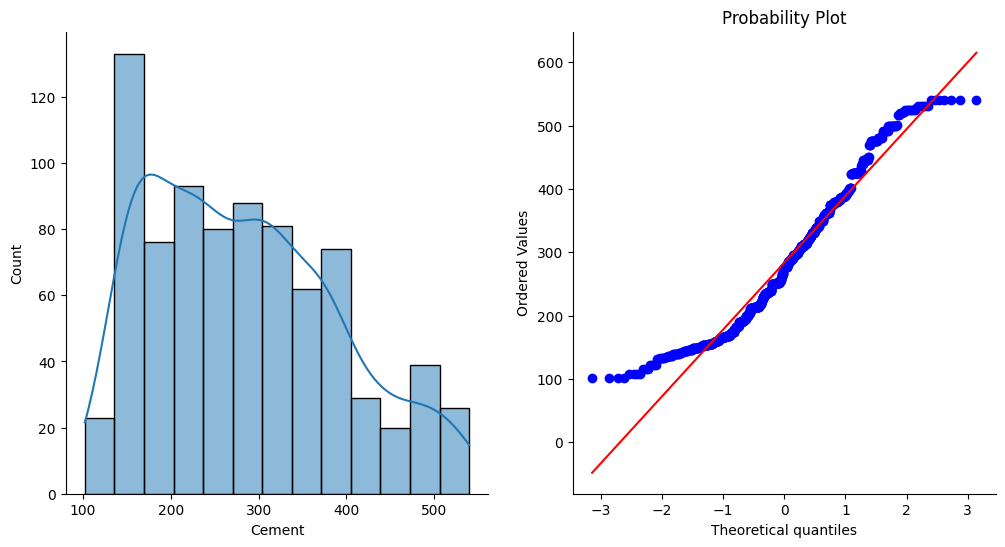

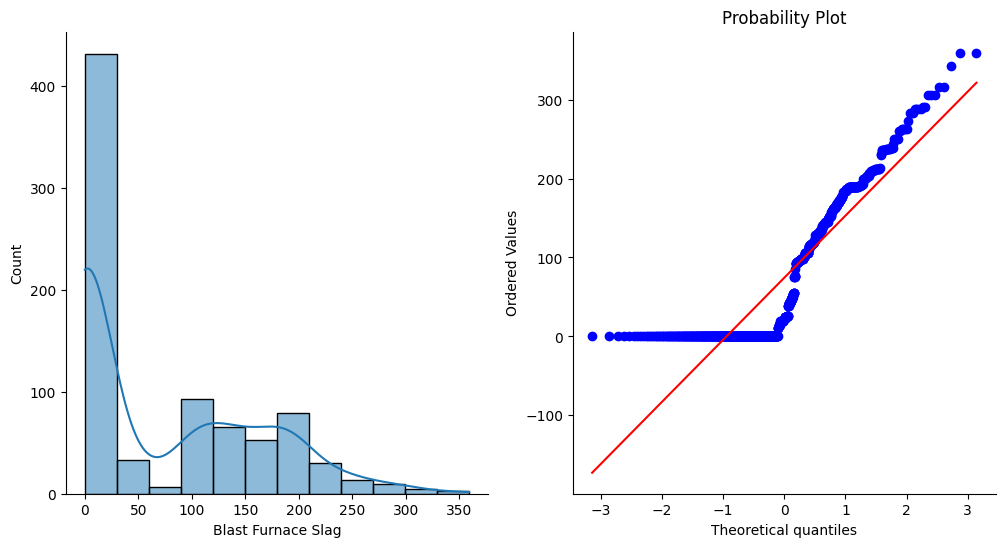

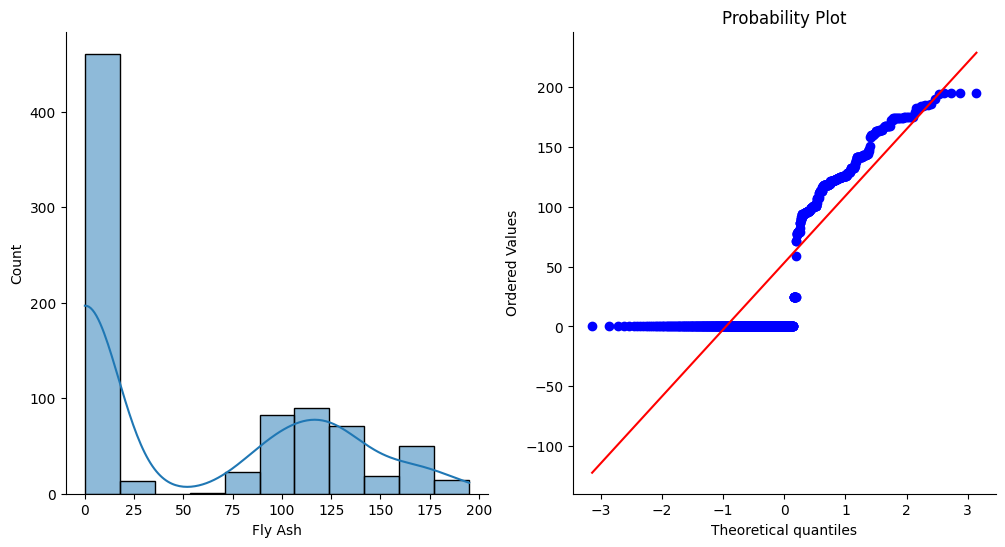

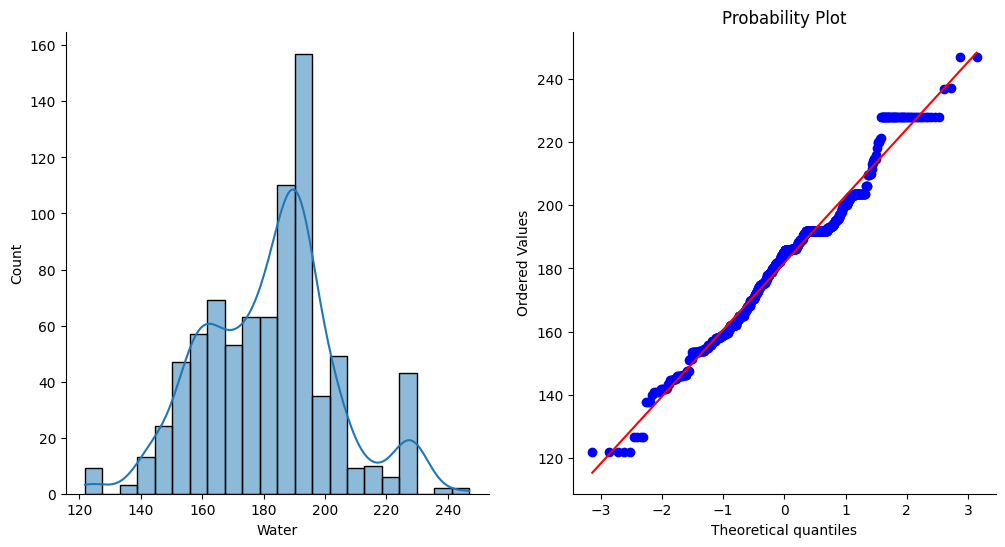

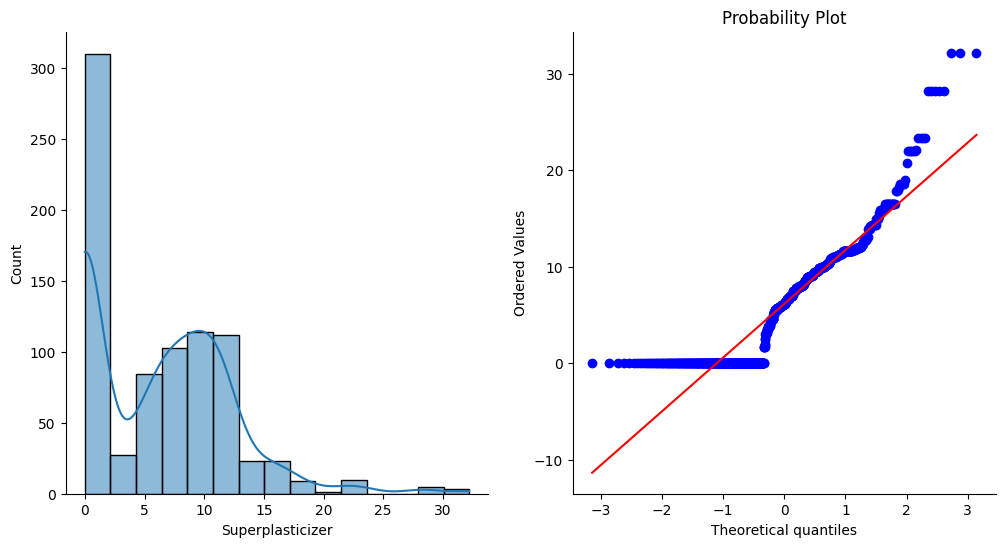

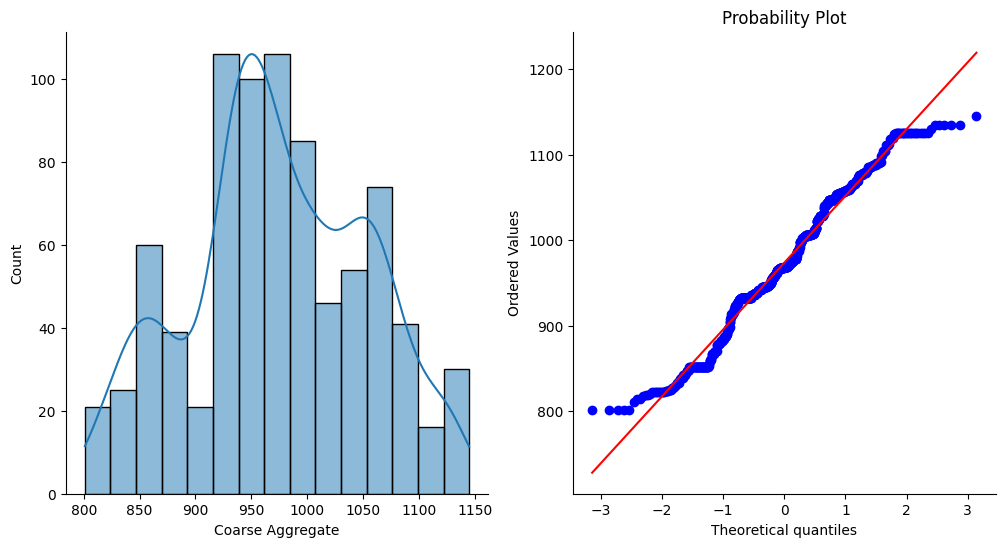

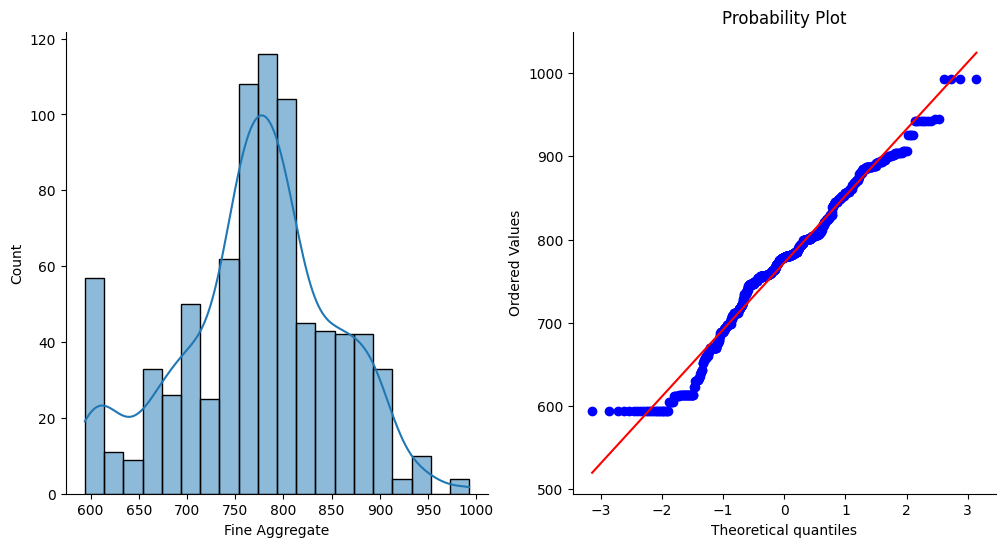

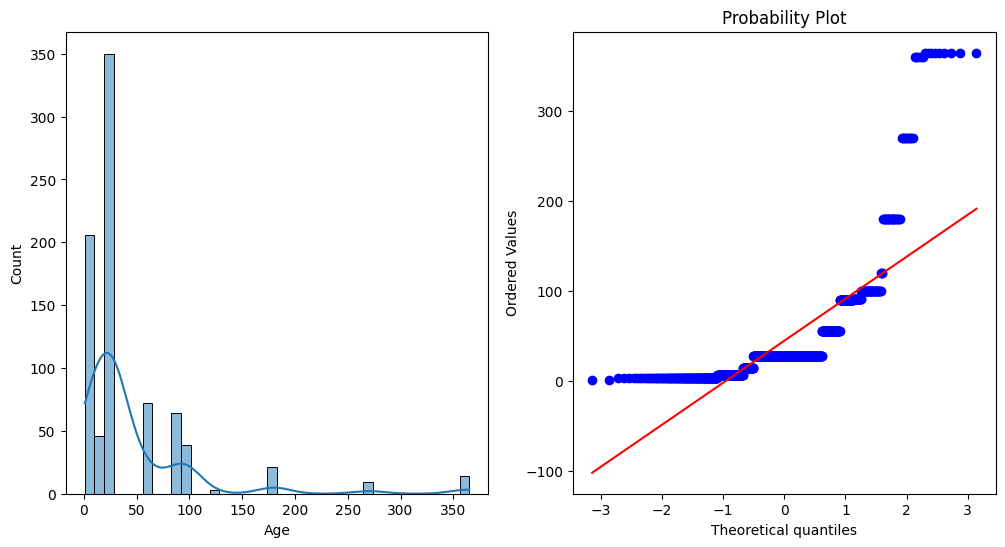

In [51]:
for col in X_train.columns:
    sns.despine()
    fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,6))

    sns.histplot(X_train[col], kde= True,  ax= ax1)
    
    stats.probplot(X_train[col], dist="norm", plot=ax2)

# Box-Cox Transform

In [52]:
bct= PowerTransformer(method='box-cox')
X_train_transformed= bct.fit_transform(X_train+0.000001)
X_test_transformed= bct.fit_transform(X_test+0.000001)
# There were some values that had 0. Since Box-Cox wont be applied on 0 we add 0.000001

# Using Linear Regression in Transformed Data

In [54]:
lr= LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred= lr.predict(X_test_transformed)
r2_score(y_test, y_pred)


0.8055321004501623

# Cross Validation in Transformed Data

In [55]:
np.mean(cross_val_score(lr, X_train_transformed, y_train, cv=5, scoring='r2'))

np.float64(0.7923976619388301)

In [56]:
X_train_transformed= pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_train_transformed

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,-1.279751,0.956151,1.128045,-0.301920,0.898506,-0.262500,-0.677568,0.106010
1,1.244706,0.701994,1.137577,-0.165055,0.749235,-1.912728,-0.314062,0.106010
2,0.079842,-1.085667,1.131407,-1.047291,0.788486,1.018407,0.025957,-1.675970
3,-0.145641,0.898125,1.096514,0.581224,0.733792,-1.750779,0.583253,0.106010
4,-1.131044,0.787203,1.133149,-1.105297,0.811152,1.368575,0.262623,-1.675970
...,...,...,...,...,...,...,...,...
819,0.183601,0.997079,-0.887212,-1.769923,0.820684,0.390563,0.358776,-1.675970
820,-0.198733,-1.085667,1.133622,-1.839129,0.838861,1.445973,0.322797,-0.475625
821,-0.844517,-1.085667,1.133681,-0.706089,0.788486,1.345367,0.297157,1.246733
822,1.565624,0.925496,-0.887212,-0.019311,0.761011,-1.537255,0.076211,0.106010


# Visualization with Box-Cox Transformation

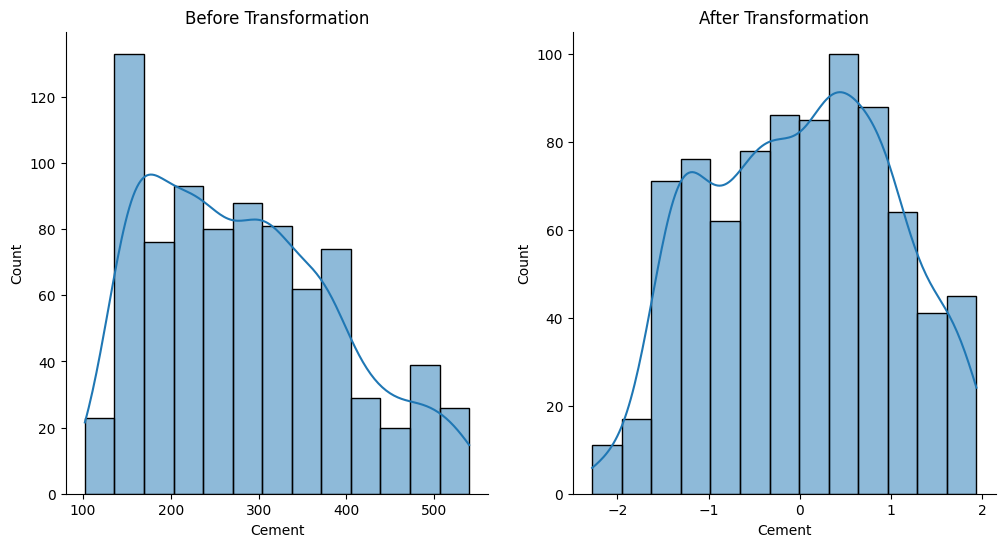

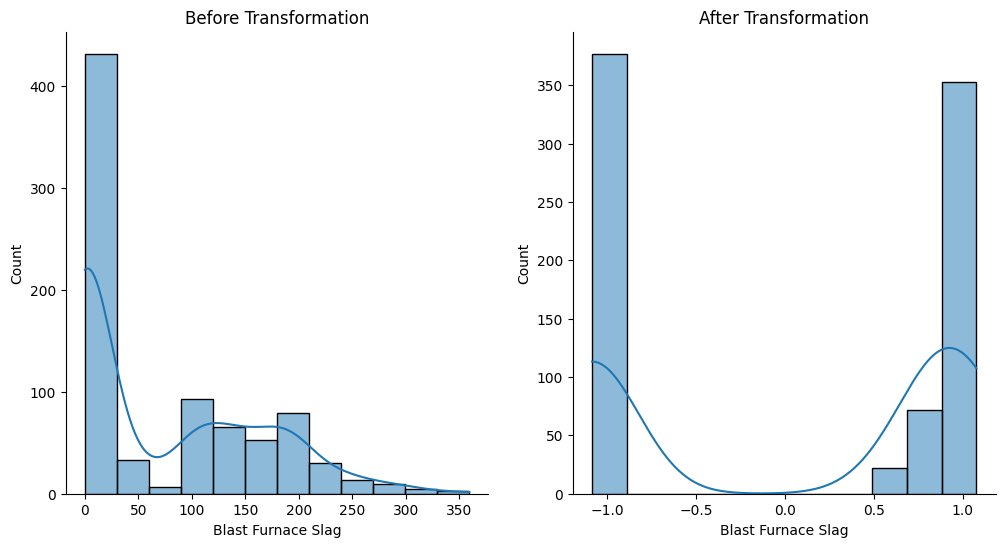

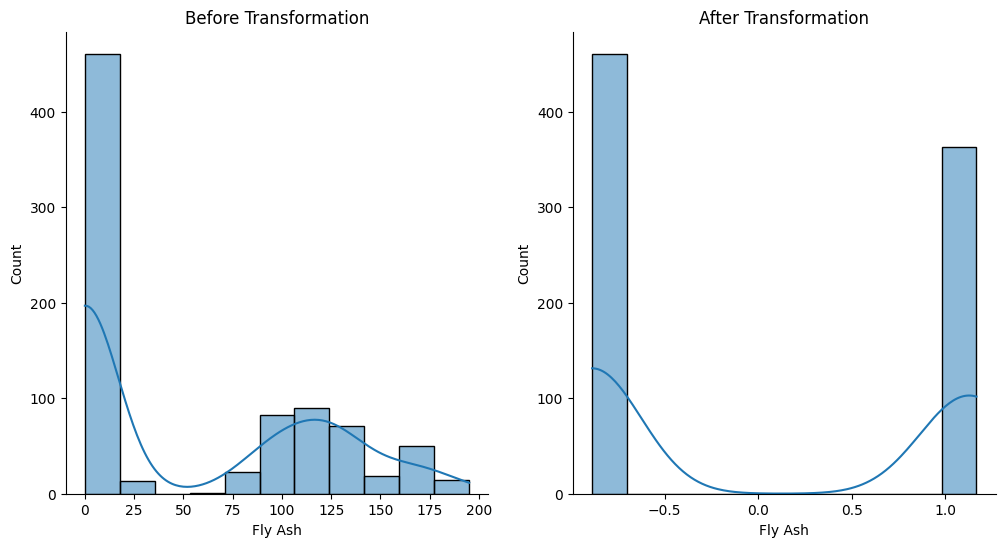

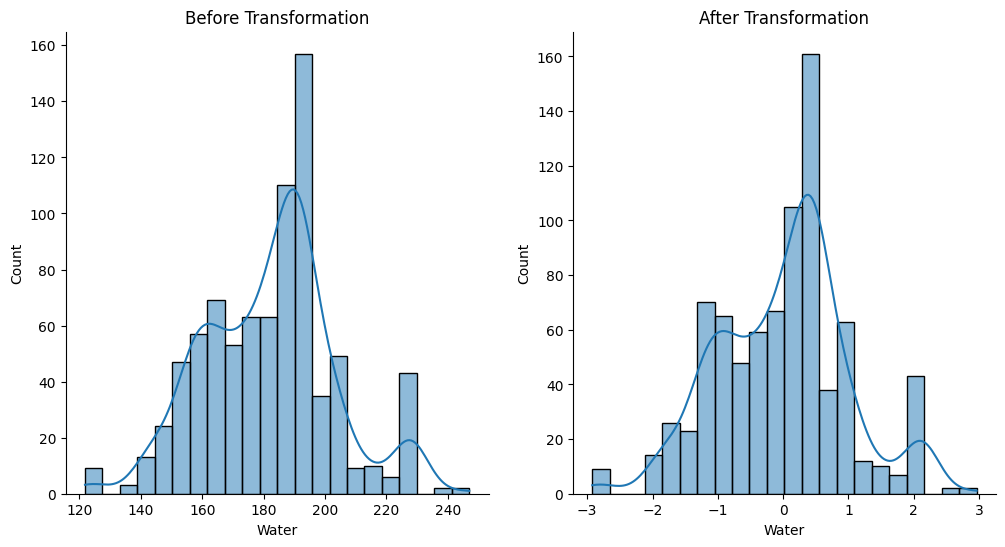

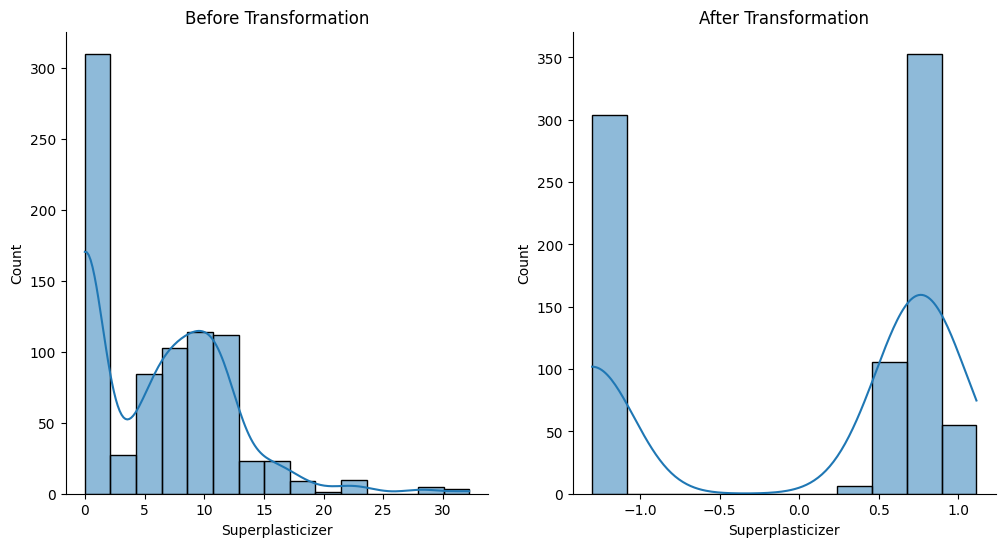

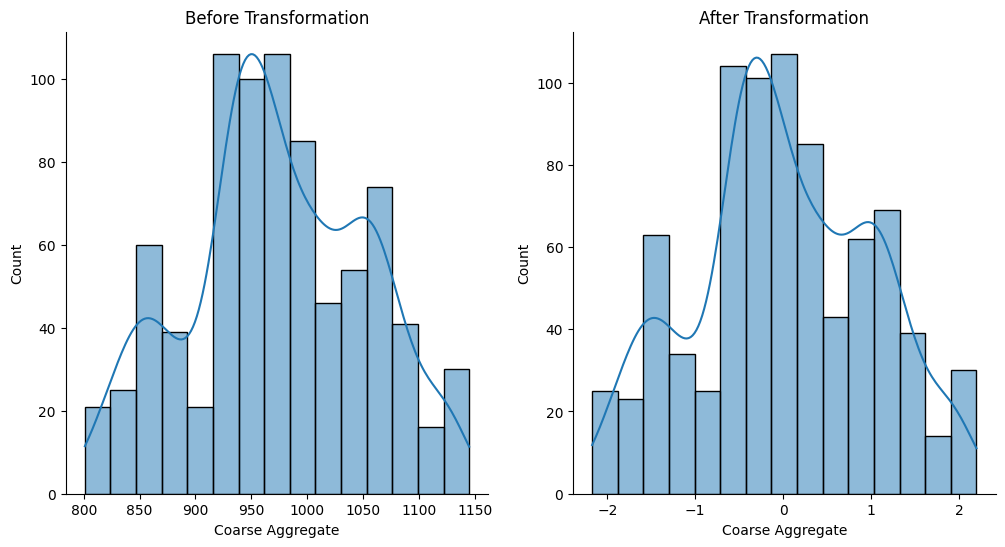

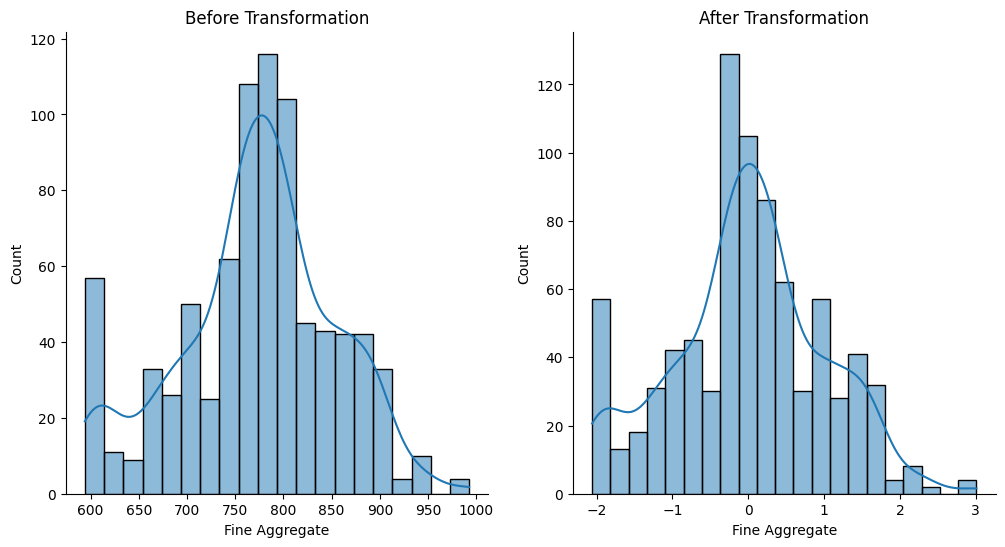

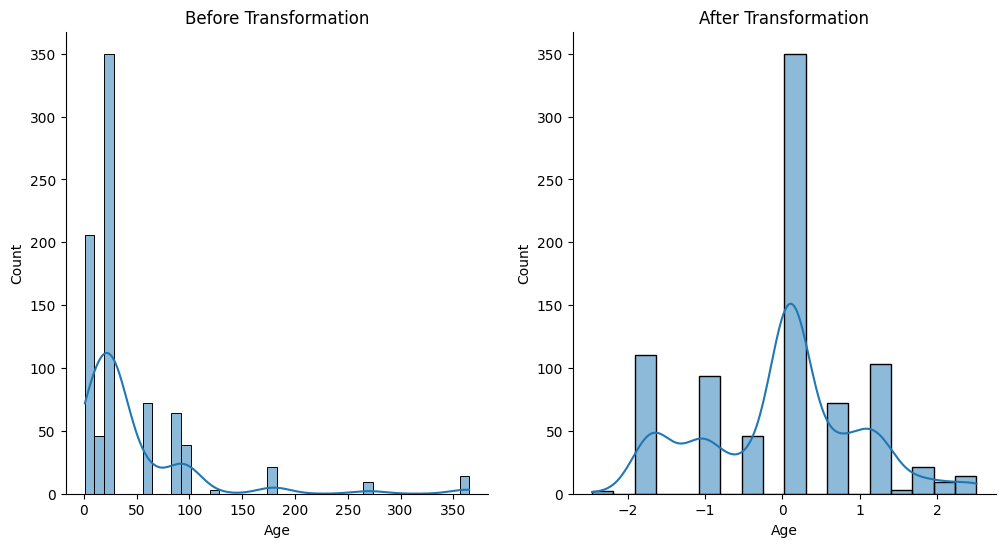

In [57]:
for col in X_train_transformed.columns:
    fig, (ax1, ax2)= plt.subplots(ncols=2, figsize=(12,6))
    sns.despine()
    sns.histplot(X_train[col], kde=True, ax= ax1)
    ax1.set_title("Before Transformation")
    sns.histplot(X_train_transformed[col], kde=True, ax= ax2)
    ax2.set_title("After Transformation")

# Yeo Johnson Transform

In [58]:
yj= PowerTransformer()
X_train_transformed2= yj.fit_transform(X_train)
X_test_transformed2= yj.transform(X_test)

# Applying Linear Regression

In [59]:
lr= LinearRegression()
lr.fit(X_train_transformed2, y_train)
y_pred= lr.predict(X_test_transformed2)
r2_score(y_test, y_pred)

0.8161906511066099

# Cross Validation

In [61]:
np.mean(cross_val_score(lr,X_train_transformed2, y_train, cv=5, scoring='r2'))

np.float64(0.7941782184607012)

In [62]:
X_train_transformed2= pd.DataFrame(X_train_transformed2, columns= X_train.columns)

# Visualization with YeoJohnson Transformation

<Figure size 640x480 with 0 Axes>

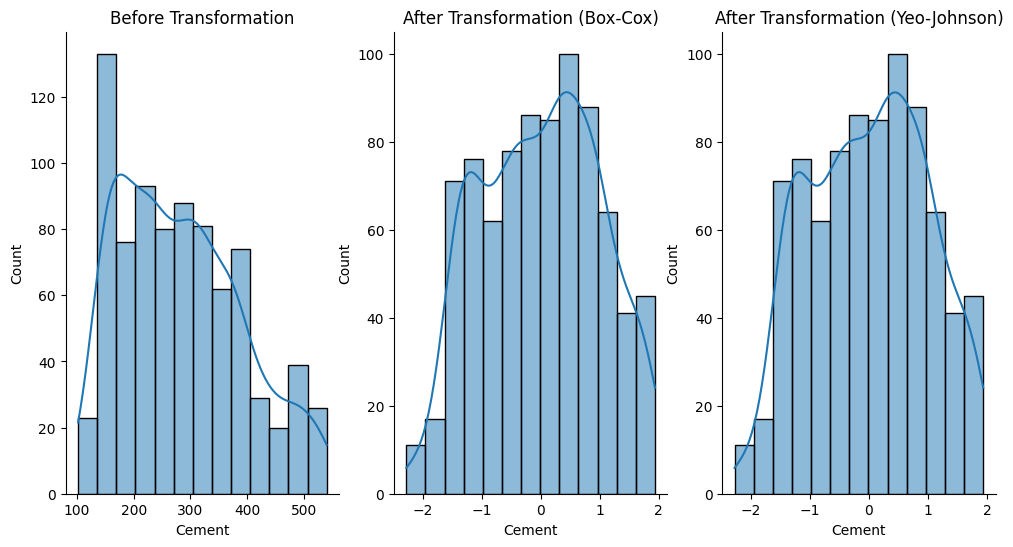

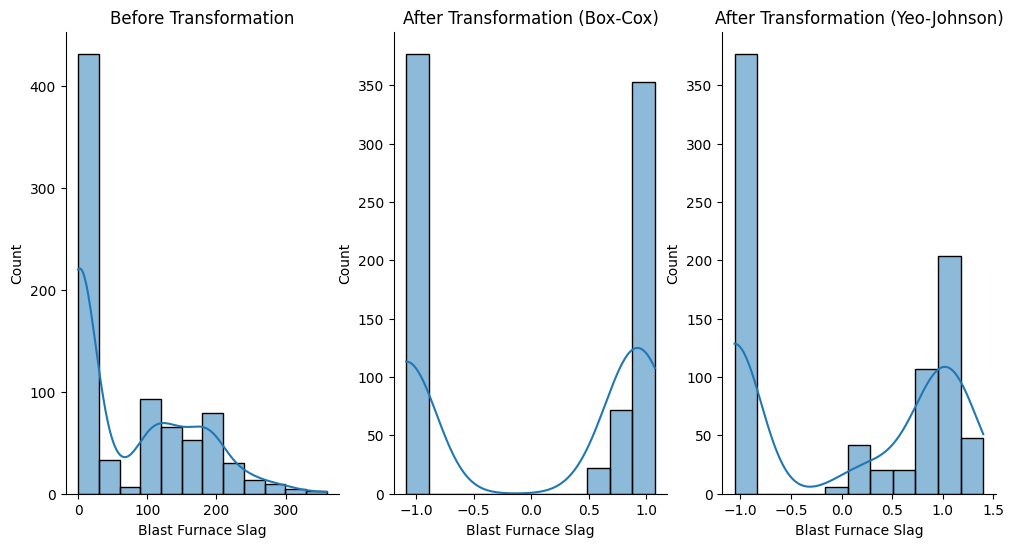

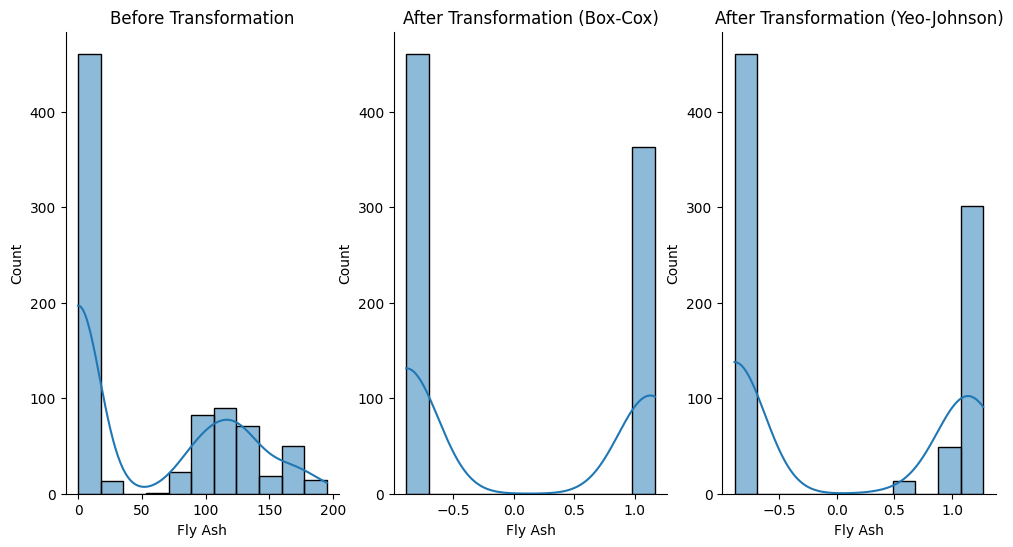

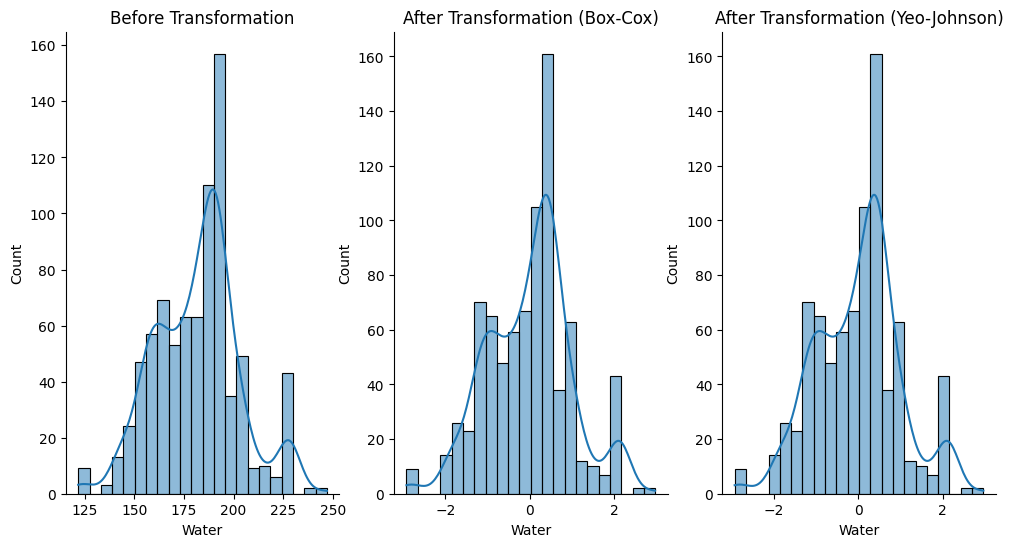

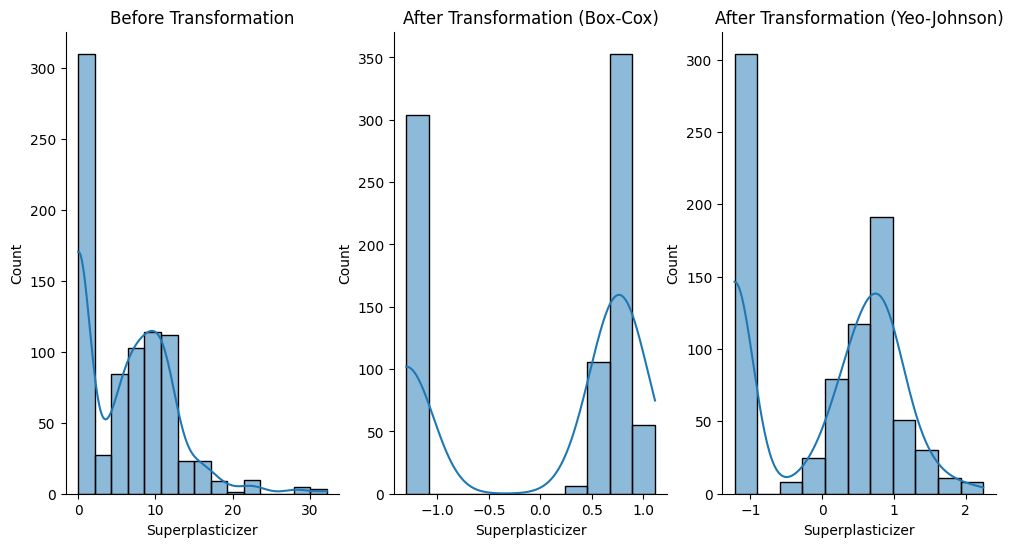

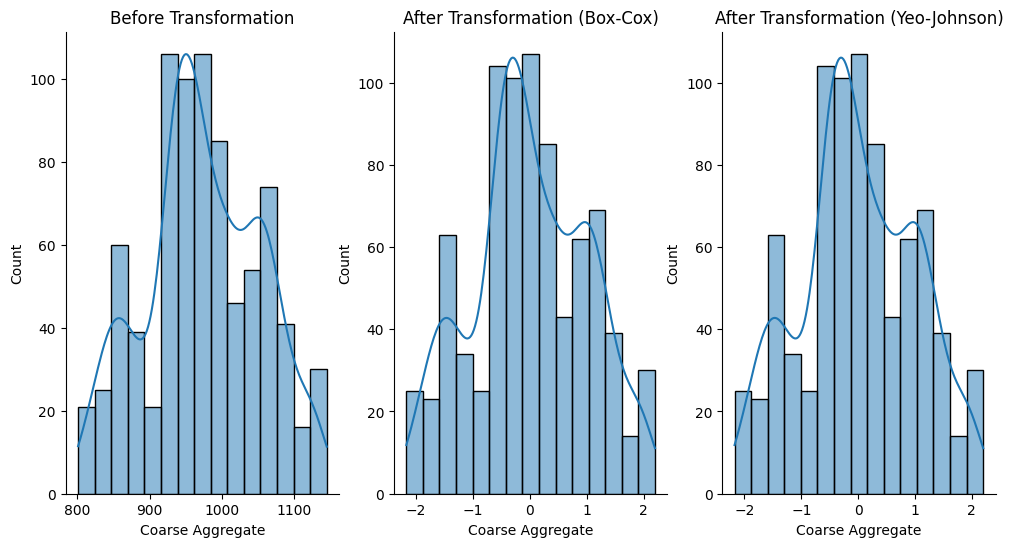

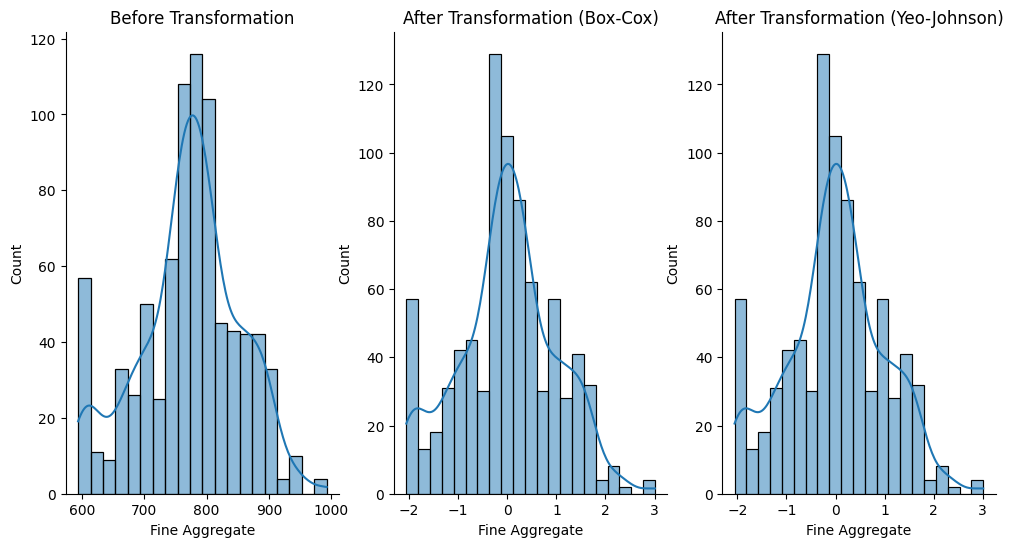

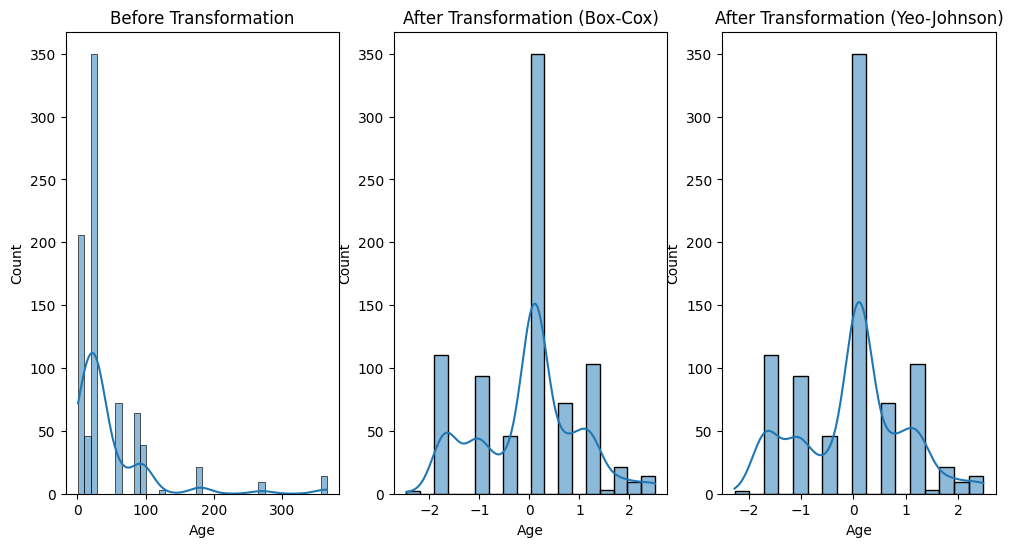

In [66]:
for col in X_train_transformed2.columns:
    sns.despine()
    fig, (ax1, ax2, ax3)= plt.subplots(ncols= 3, figsize=(12,6))

    sns.histplot(X_train[col], kde=True, ax= ax1)
    ax1.set_title("Before Transformation")

    sns.histplot(X_train_transformed[col], kde=True, ax=ax2)
    ax2.set_title("After Transformation (Box-Cox)")

    sns.histplot(X_train_transformed2[col], kde=True, ax= ax3)
    ax3.set_title("After Transformation (Yeo-Johnson)")

# Values of lambdas

In [67]:
pd.DataFrame({'cols':X_train.columns, 'box_cox_lambdas':bct.lambdas_, 'yeo_johnson_lambdas': yj.lambdas_})

,cols,box_cox_lambdas,yeo_johnson_lambdas
0,Cement,0.215602,0.174348
1,Blast Furnace Slag,0.025996,0.015715
2,Fly Ash,-0.006544,-0.161447
3,Water,0.959062,0.771307
4,Superplasticizer,0.103365,0.253935
5,Coarse Aggregate,1.192492,1.130050
6,Fine Aggregate,1.973781,1.783100
7,Age,-0.014692,0.019885
